<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/TimeSeriesForecasting/W9/combining_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Combining models
In this notebook we'll go trhough some examples of how we can combine different forecasting models and techniques.

In [1]:
%%capture
!pip install statsforecast
!pip install utilsforecast
!pip install statsmodels
!pip install fpppy

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

sns.set_style("whitegrid")

from functools import partial, reduce
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
from statsforecast.adapters.prophet import AutoARIMAProphet
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf
from utilsforecast.plotting import plot_series as plot_series_utils
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.preprocessing import fill_gaps

plt.style.use("ggplot")
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=['#128698','#841298', '#981212', '#098765', '#000009'])

np.random.seed(1)
pd.set_option("display.precision", 3)
np.set_printoptions(suppress=True)
os.environ["NIXTLA_ID_AS_COL"] = "1"

from fpppy.utils import plot_series

# Complex seasonality example
High frequency time series often exhibit more complicated seasonal patterns. For example, daily data may have a weekly pattern as well as an annual pattern. Hourly data usually has three types of seasonality: a daily pattern, a weekly pattern, and an annual pattern.

We don’t necessarily want to include all of the possible seasonal periods in our models — just the ones that are likely to be present in the data.
Let's take for example the number of calls to a North American commercial bank per 5-minute interval between 7:00am and 9:05pm each weekday over a 33 week period.

In [3]:
df = pd.read_csv("https://otexts.com/fpppy/data/bank_calls.csv", parse_dates=["ds"], date_format='%Y-%m-%d %H:%M:%S')

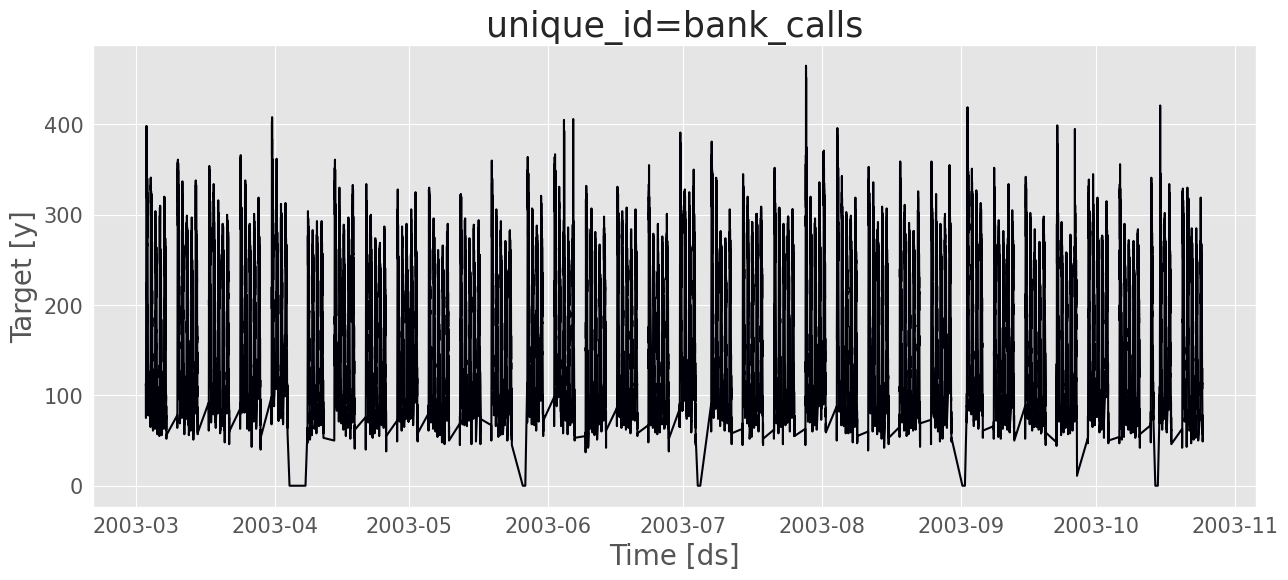

In [4]:
plot_series(df)

A method to forecast timeseries with multiple seasonalities is the `MSTL()`: and it can be used to decompose a series into its trend, multiple seasonal, and remainder components.

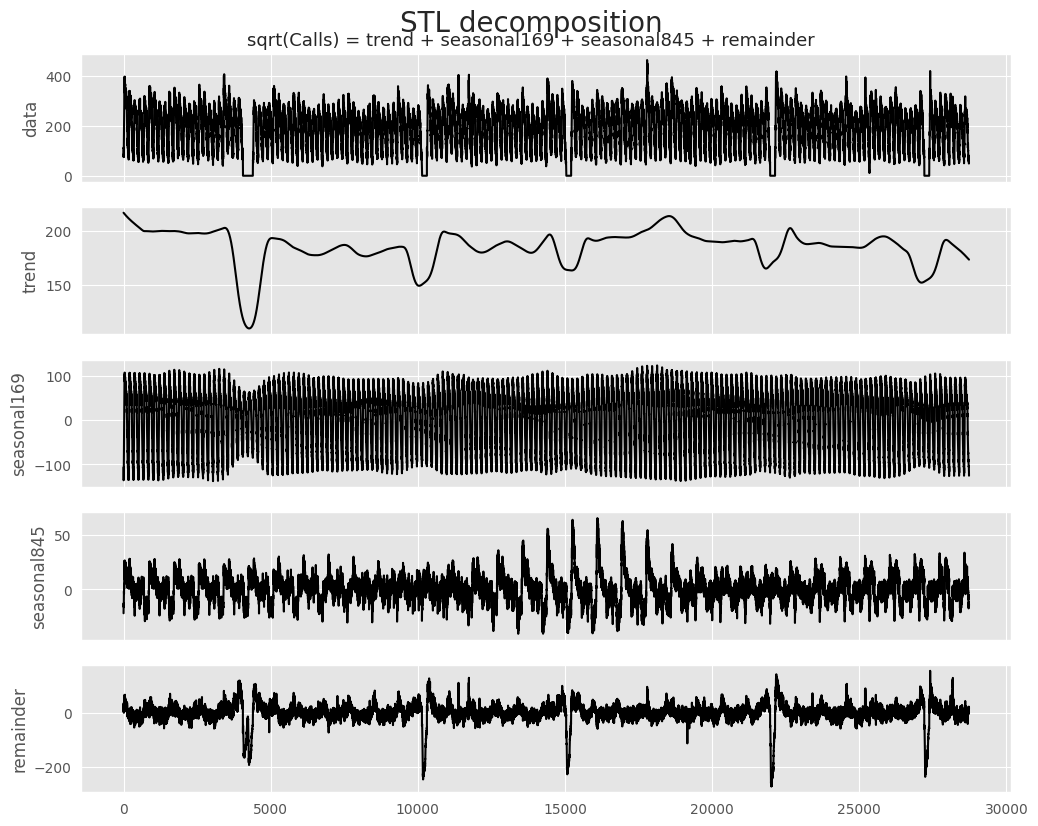

In [5]:
sf = StatsForecast(models=[MSTL(season_length=[169, 169 * 5])], freq="5min")

sf = sf.fit(df)
dcmp = sf.fitted_[0, 0].model_

def plot_decomposition(dcmp):
  fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 9), sharex=True)
  sns.lineplot(data=dcmp, x=dcmp.index, y="data", ax=axes[0], color="black")
  sns.lineplot(data=dcmp, x=dcmp.index, y="trend", ax=axes[1], color="black")
  sns.lineplot(data=dcmp, x=dcmp.index, y="seasonal169", ax=axes[2], color="black")
  sns.lineplot(data=dcmp, x=dcmp.index, y="seasonal845", ax=axes[3], color="black")
  sns.lineplot(data=dcmp, x=dcmp.index, y="remainder", ax=axes[4], color="black")
  fig.suptitle("STL decomposition", fontsize=20)
  fig.subplots_adjust(top=0.93)
  fig.text(0.5, 0.94, "sqrt(Calls) = trend + seasonal169 + seasonal845 + remainder",
          fontsize=13, ha='center')
  plt.xlabel("")
  plt.show()

plot_decomposition(dcmp)

There are two seasonal patterns shown, one for the time of day (the third panel), and one for the time of week (the fourth panel). Note that in this case, there is little trend seen in the data, and the weekly seasonality is weak.

The `MSTL` method **can also be used for forecasting**, as shown below. Since StatsForecast always produces continuous dates, we need to account for the bank being closed before 7:00am, after 9:05pm, and on weekends. We will do this by generating the correct dates directly, using the knowledge that the dataset we used to generate the forecast ends on Friday the 24th at 9:05 PM.

<ipython-input-6-7e1851ad09d3>:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(start="2003-10-27 07:00:00", periods = 169 * 5, freq="5T")
/usr/local/lib/python3.11/dist-packages/utilsforecast/preprocessing.py:131: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


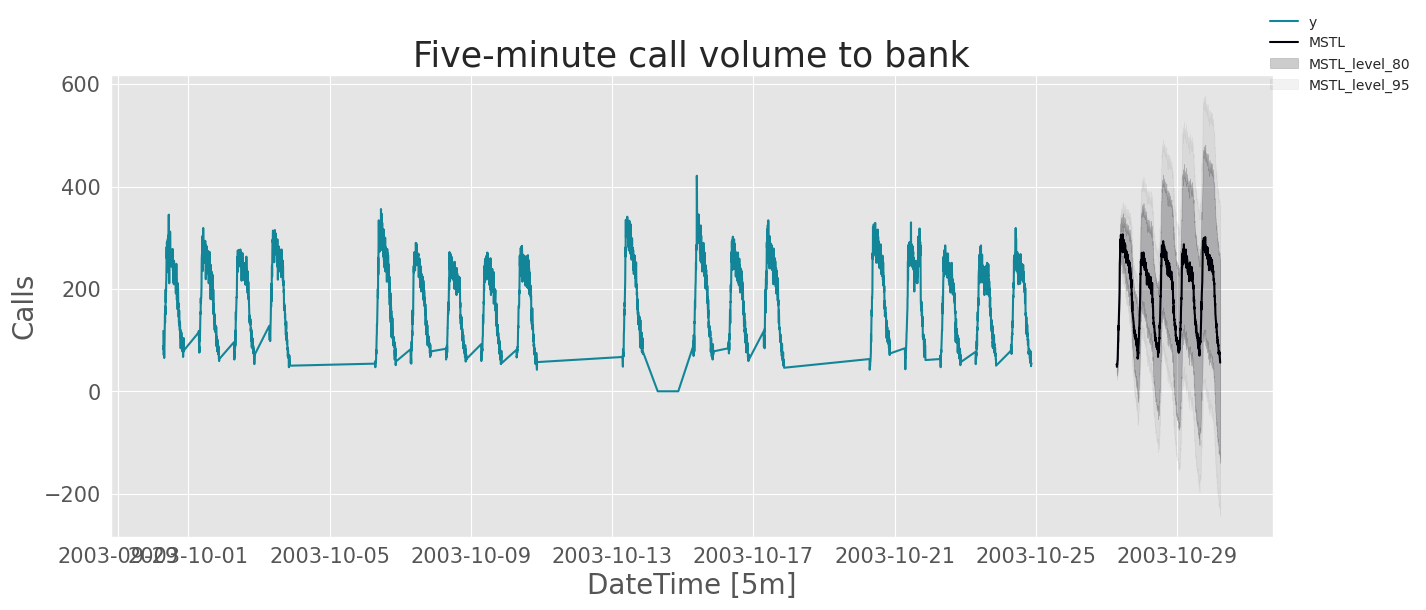

In [6]:
fc = sf.predict(h=169 * 5, level=[80, 95])

dates = pd.date_range(start="2003-10-27 07:00:00", periods = 169 * 5, freq="5T")
fc["ds"] = dates
fc = fc[fc["ds"].dt.weekday <= 4]
fc = fill_gaps(fc, freq="5T")

plot_series(df, fc, level=[80, 95],
            max_insample_length=169 * (14 + 5),
            xlabel="DateTime [5m]", ylabel="Calls",
            title="Five-minute call volume to bank", rm_legend=False)

# A second look at the distribution
Seems like our forecast is not super stable. This is likely due to the

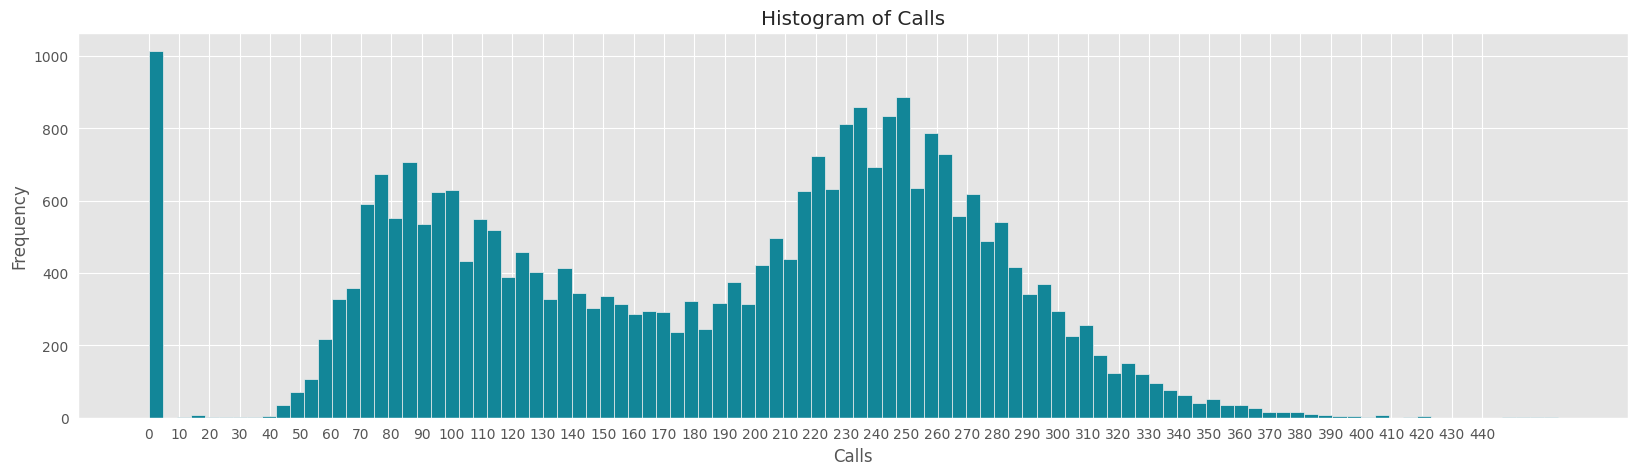

In [7]:
df['y'].hist(bins=100, figsize=(20, 5))
plt.xticks(np.arange(0, 450, 10))
plt.title("Histogram of Calls")
plt.xlabel("Calls")
plt.ylabel("Frequency")
plt.show()

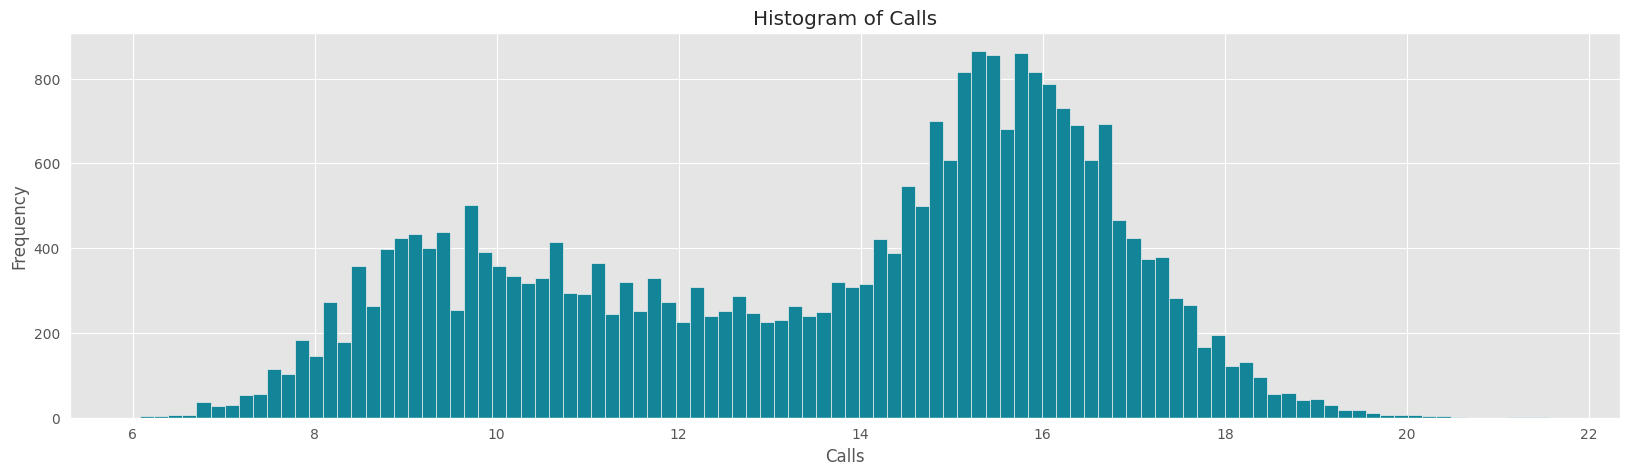

In [8]:
df.loc[df['y'] < 35, 'y'] = np.nan
df.dropna(inplace=True)

df['y'] = np.sqrt(df['y'])
df['y'].hist(bins=100, figsize=(20, 5))
plt.title("Histogram of Calls")
plt.xlabel("Calls")
plt.ylabel("Frequency")
plt.show()


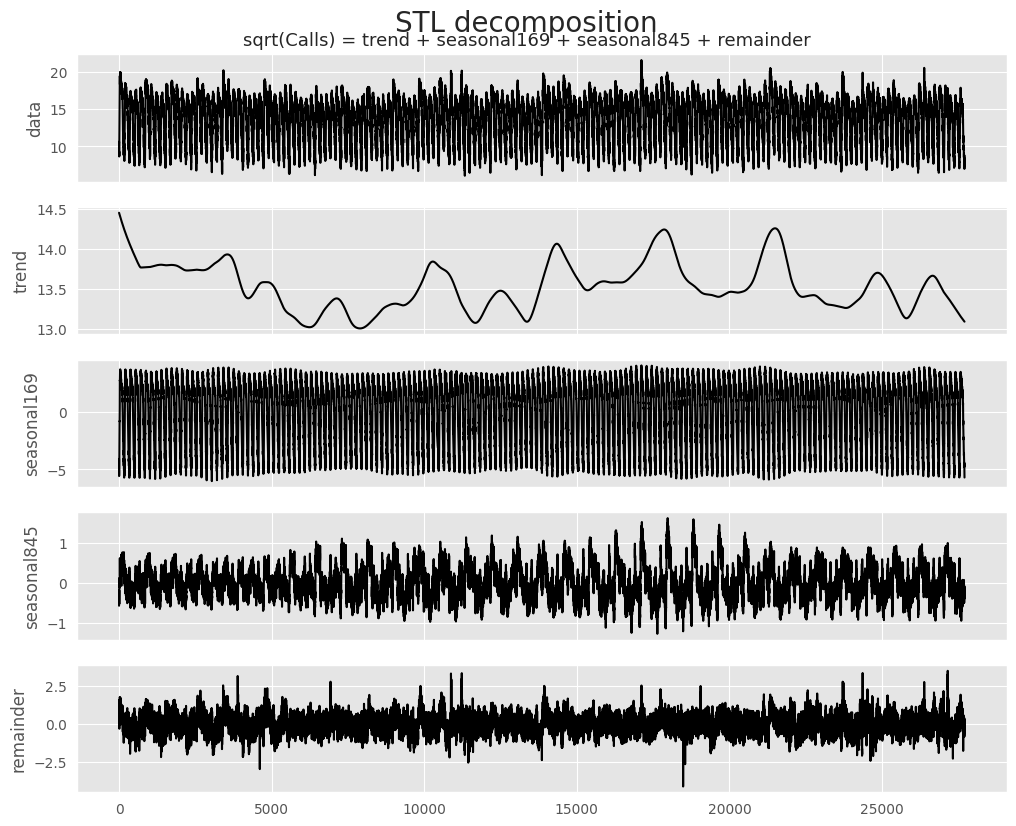

In [9]:
sf = sf.fit(df)
dcmp = sf.fitted_[0, 0].model_
plot_decomposition(dcmp)

<ipython-input-10-7e1851ad09d3>:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(start="2003-10-27 07:00:00", periods = 169 * 5, freq="5T")
/usr/local/lib/python3.11/dist-packages/utilsforecast/preprocessing.py:131: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


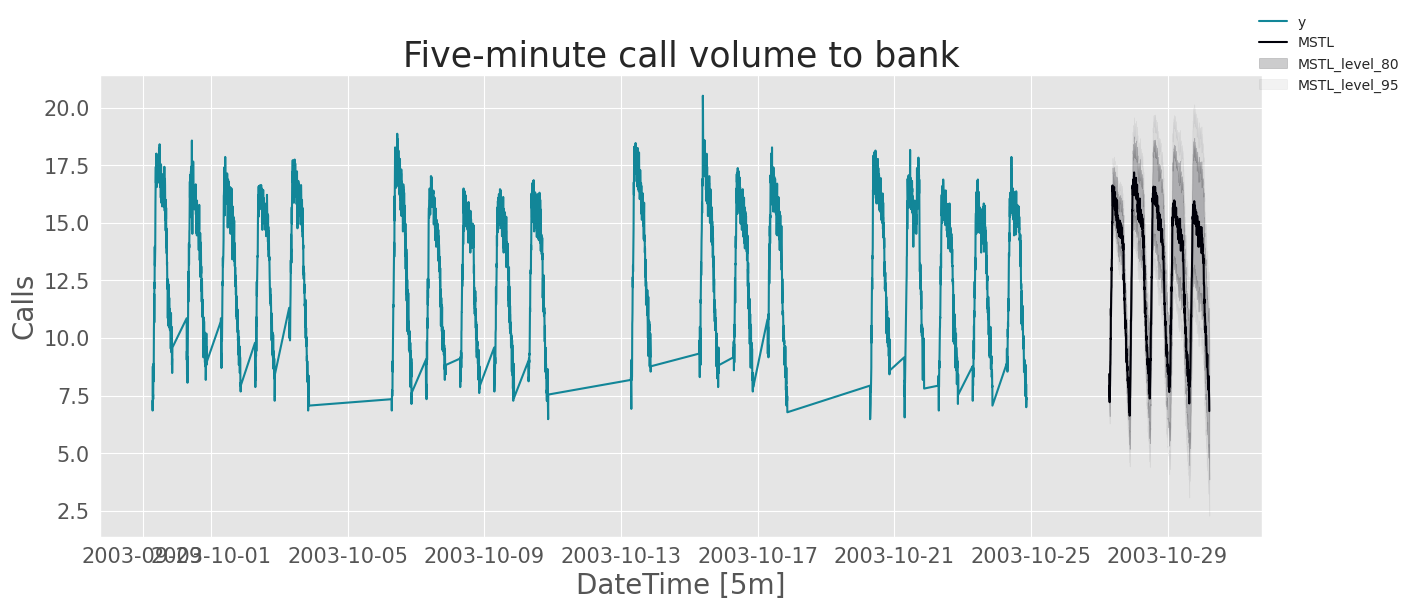

In [10]:
fc = sf.predict(h=169 * 5, level=[80, 95])

dates = pd.date_range(start="2003-10-27 07:00:00", periods = 169 * 5, freq="5T")
fc["ds"] = dates
fc = fc[fc["ds"].dt.weekday <= 4]
fc = fill_gaps(fc, freq="5T")

plot_series(df, fc, level=[80, 95],
            max_insample_length=169 * (14 + 5),
            xlabel="DateTime [5m]", ylabel="Calls",
            title="Five-minute call volume to bank", rm_legend=False)

# Dynamic harmonic regression with multiple seasonal periods
For seasonal data we can use Fourier decomposition as we did before. When we select specific seasonalities, the model is named dynamic harmonic regression.
We will apply it to half-hourly electricity demand (MWh) in Victoria, Australia, during 2012–2014, along with temperatures (degrees Celsius) for the same period for Melbourne (the largest city in Victoria).
For this case,

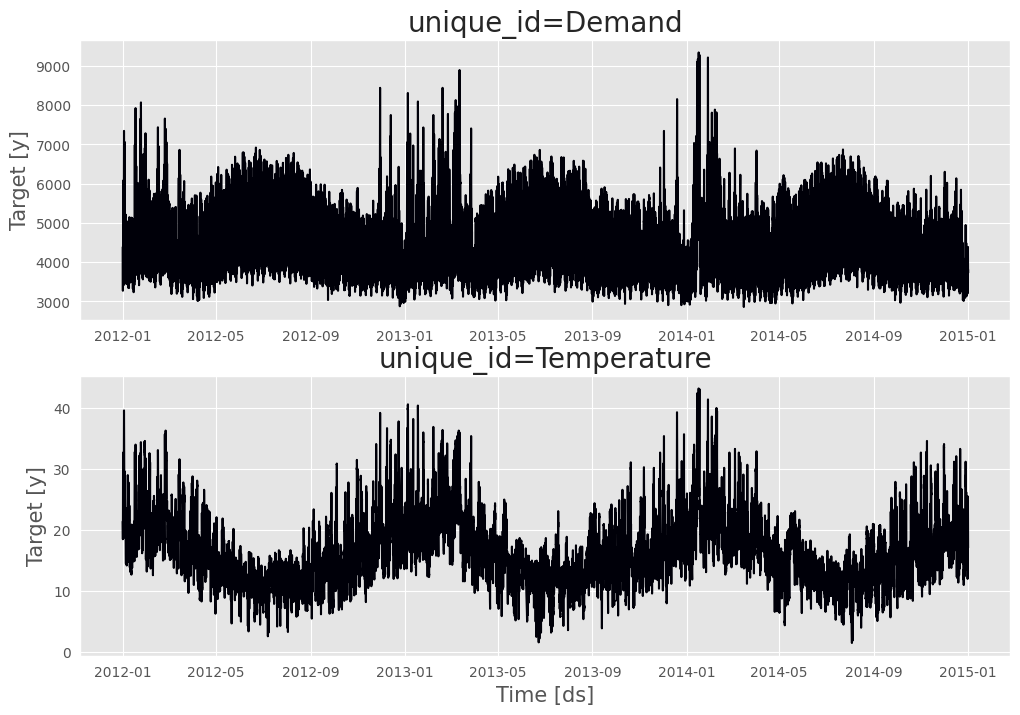

In [11]:
vic_elec = pd.read_csv("https://otexts.com/fpppy/data/vic_elec.csv", parse_dates=['ds'])
_, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))
fig = plot_series_utils(vic_elec, ax=axes)
for ax in fig.axes:
    ax.title.set_fontsize(20)
    ax.xaxis.label.set_fontsize(15)
    ax.yaxis.label.set_fontsize(15)
    ax.tick_params(axis='both', labelsize=10)
    if ax.get_legend():
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(0)
fig.legends = []
fig

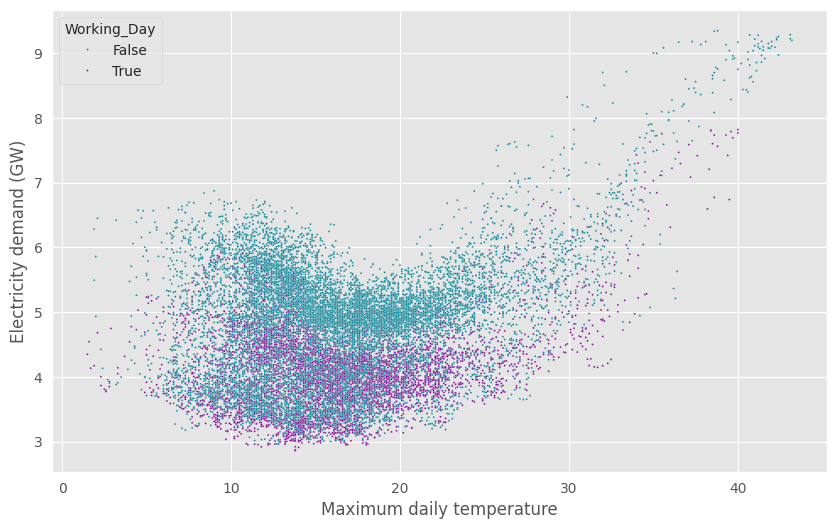

,unique_id,ds,Demand,Temperature,Holiday,Day_Week,Working_Day,Cooling
35084,VIC,2014-01-01 00:00:00,4.092,18.7,True,2,False,18.7
35085,VIC,2014-01-01 00:30:00,4.198,18.1,True,2,False,18.1
35086,VIC,2014-01-01 01:00:00,3.915,18.2,True,2,False,18.2
35087,VIC,2014-01-01 01:30:00,3.673,17.9,True,2,False,18.0
35088,VIC,2014-01-01 02:00:00,3.498,17.6,True,2,False,18.0


In [25]:
vic_elec_df = vic_elec.pivot(index = 'ds', columns = 'unique_id', values = 'y').reset_index()
vic_elec_df = vic_elec_df.merge(vic_elec[['ds', 'Holiday']].drop_duplicates(), on = 'ds')
#vic_elec_df.set_index('ds', inplace=True)


vic_elec_df['Demand'] = vic_elec_df['Demand']/1e3
vic_elec_df.insert(0, 'unique_id', 'VIC')
vic_elec_df = vic_elec_df.query('ds >= "2014-01-01"')
vic_elec_df['Day_Week'] = vic_elec_df['ds'].dt.dayofweek
vic_elec_df["Working_Day"] = vic_elec_df['Day_Week'].isin([5, 6])
vic_elec_df["Cooling"] = np.maximum(vic_elec_df["Temperature"], 18)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=vic_elec_df, x='Temperature', y='Demand', hue='Working_Day', s=2)
plt.xlabel('Maximum daily temperature')
plt.ylabel('Electricity demand (GW)')
plt.show()

vic_elec_df.head()

### Generating features and training
The utilsforecast's `pipeline` is an helper function for preprocessing time series data and generating features.
We will fit a regression model with a piecewise linear function of temperature (containing a knot at 18 degrees), and harmonic regression terms to allow for the daily seasonal pattern. We set the orders of the Fourier terms subjectively, while using the AICc to select the order of the ARIMA errors.

In [13]:
vic_elec_df = vic_elec_df.drop(columns=["Holiday", "Day_Week"])
vic_elec_df = vic_elec_df.rename(columns={"Demand": "y"})

features = [
    partial(fourier, season_length=2 * 24, k=10),
    partial(fourier, season_length=2 * 24 * 7, k=5),
    partial(fourier, season_length=2 * 24 * 7 * 365, k=3),
]

# we decrease the total number of samples for the training to reduce fitting time
vic_elec_fourier, vic_elec_futr_fourier = pipeline(
    vic_elec_df.tail(5000),
    features=features,
    freq='30min',
    h=2 * 48
)
sf = StatsForecast(
    models=[AutoARIMA(max_d=0, seasonal=False, nmodels=20, approximation=True)],
    freq='30min'
)
sf = sf.fit(vic_elec_fourier)

/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 1]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsforecast/arima.py:479: UserWarning: possible convergenc

### Forecasting step
Forecasting with such models is difficult because we require future values of the predictor variables. Future values of the Fourier terms are easy to compute, but future temperatures are, of course, unknown. If we are only interested in forecasting up to a week ahead, we could use temperature forecasts obtained from a meteorological model. In the following example, we have used a repeat of the last two days of temperatures to generate future possible demand values.

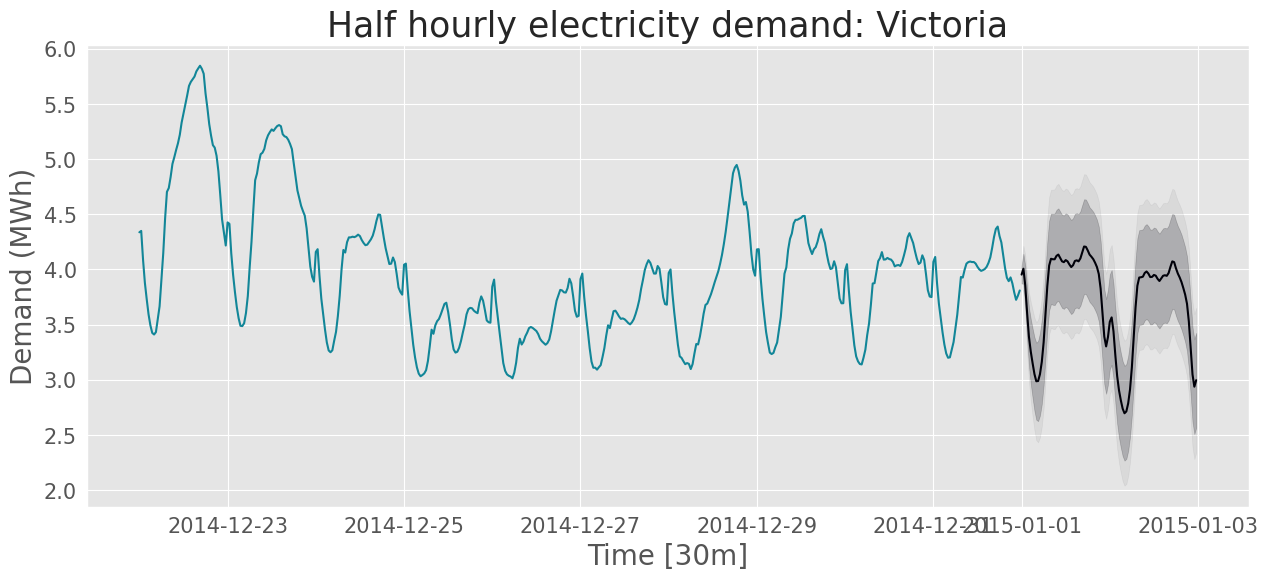

In [14]:
# obtain future values of temperature, cooling and working day
for col in ["Temperature", "Cooling", "Working_Day"]:
    vic_elec_futr_fourier[col] = vic_elec_df[col].tail(2 * 48).values

fc_fourier = sf.predict(h=2 * 48, X_df=vic_elec_futr_fourier[vic_elec_fourier.columns.drop("y")], level=[80, 95])
plot_series(
    vic_elec_fourier, fc_fourier, level=[80, 95], max_insample_length=10 * 48,
    xlabel="Time [30m]",
    ylabel="Demand (MWh)",
    title="Half hourly electricity demand: Victoria",
)

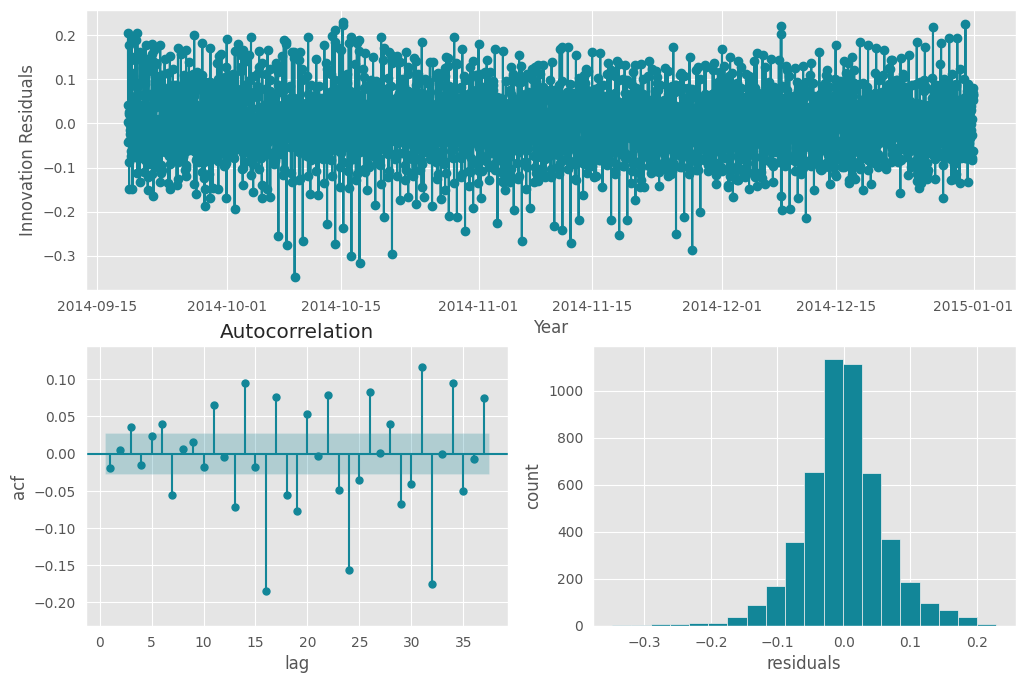

In [15]:
residuals = sf.fitted_[0, 0].model_["residuals"]

fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ax1.plot(vic_elec_fourier["ds"], residuals, marker="o")
ax1.set_ylabel("Innovation Residuals")
ax1.set_xlabel("Year")

plot_acf(residuals, ax2,
         zero=False,
         bartlett_confint=False,
         auto_ylims=True)
ax2.set_ylabel("acf")
ax2.set_xlabel("lag")

ax3.hist(residuals, bins=20)
ax3.set_ylabel("count")
ax3.set_xlabel("residuals")

plt.show()

Although the short-term forecasts look reasonable, this is a crude model for a complicated process. The residuals, plotted in Figure 12.9, demonstrate that there is a lot of information that has not been captured with this model.



# Prophet
This model was introduced by Facebook (Taylor and Letham 2018), originally for forecasting daily data with weekly and yearly seasonality, plus holiday effects. It was later extended to cover more types of seasonal data. It works best with time series that have strong seasonality and several seasons of historical data. Prophet can be considered a nonlinear regression model of the form:
$$y_t=g(t)+s(t)+h(t)+\varepsilon_t$$
where $g(t)$ describes a piecewise-linear trend (or “growth term”), $s(t)$ describes the various seasonal patterns, $h(t)$  captures the holiday effects, and $\varepsilon_t$ is a white noise error term.

* The knots (or changepoints) for the piecewise-linear trend are automatically selected if not explicitly specified. Optionally, a logistic function can be used to set an upper bound on the trend.
* The seasonal component consists of Fourier terms of the relevant periods. By default, order 10 is used for annual seasonality and order 3 is used for weekly seasonality.
* Holiday effects are added as simple dummy variables.
* The model is estimated using a Bayesian approach to allow for automatic selection of the changepoints and other model characteristics.

DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_5zwm1r/gzt4g435.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_5zwm1r/8xa1951a.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11164', 'data', 'file=/tmp/tmpq_5zwm1r/gzt4g435.json', 'init=/tmp/tmpq_5zwm1r/8xa1951a.json', 'output', 'file=/tmp/tmpq_5zwm1r/prophet_model31wnb8o4/prophet_model-20250430055850.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:58:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:00:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


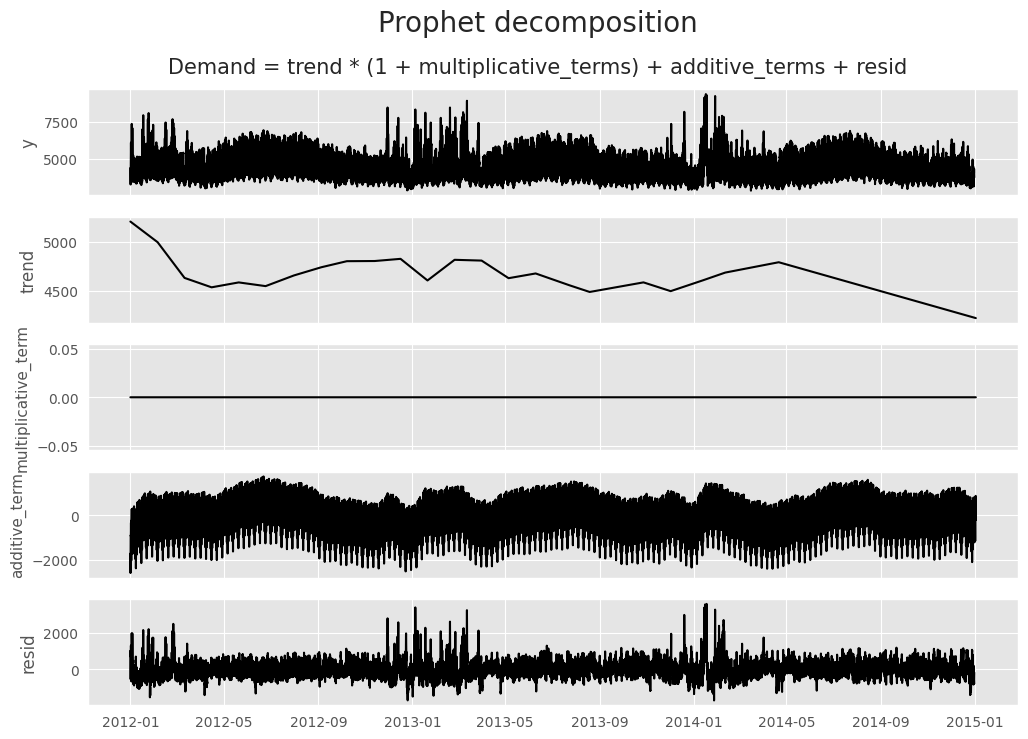

In [18]:
elec = pd.read_csv("https://otexts.com/fpppy/data/vic_elec.csv", parse_dates=['ds'])
vic_demand = elec.query('unique_id == "Demand"').drop("Holiday", axis=1)[
    ["unique_id", "ds", "y"]
]

train = vic_demand.iloc[:-48]
test = vic_demand.iloc[-48:]

m = Prophet()
m.add_seasonality(name="hourly", period=48, fourier_order=5)
m.add_seasonality(name="subhourly", period=48 * 7, fourier_order=5)
m.fit(train)

future = m.make_future_dataframe(periods=48 * 2, freq="30T")
fc_prophet = m.predict(future)
fc_prophet.rename(
    columns={
        "yhat": "Prophet",
        "yhat_lower": "Prophet-lo-80",
        "yhat_upper": "Prophet-hi-80",
    },
    inplace=True,
)
fc_prophet["resid"] = train["y"] - fc_prophet["Prophet"]

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 8), sharex=True)
sns.lineplot(data=train, x=fc_prophet["ds"], y="y", ax=axes[0], color="black")
sns.lineplot(data=fc_prophet, x=fc_prophet["ds"], y="trend", ax=axes[1], color="black")
sns.lineplot(data=fc_prophet, x=fc_prophet["ds"], y="multiplicative_terms", ax=axes[2], color="black")
axes[2].set_ylabel("multiplicative_term", fontsize=11)
sns.lineplot(data=fc_prophet, x=fc_prophet["ds"], y="additive_terms", ax=axes[3], color="black")
axes[3].set_ylabel("additive_term", fontsize=11)
sns.lineplot(data=fc_prophet, x=fc_prophet["ds"], y="resid", ax=axes[4], color="black")
fig.suptitle("Prophet decomposition", fontsize=20)
fig.text(0.5, 0.9,
         "Demand = trend * (1 + multiplicative_terms) + additive_terms + resid",
         fontsize=15,
         ha='center')
plt.xlabel("")
plt.show()

The model specification is very similar to the DHR model in the previous section, although the result is different in several important ways. The Prophet model adds a piecewise linear time trend which is not really appropriate here as we don’t expect the long term forecasts to continue to follow the downward linear trend at the end of the series.

There is also substantial remaining autocorrelation in the residuals:



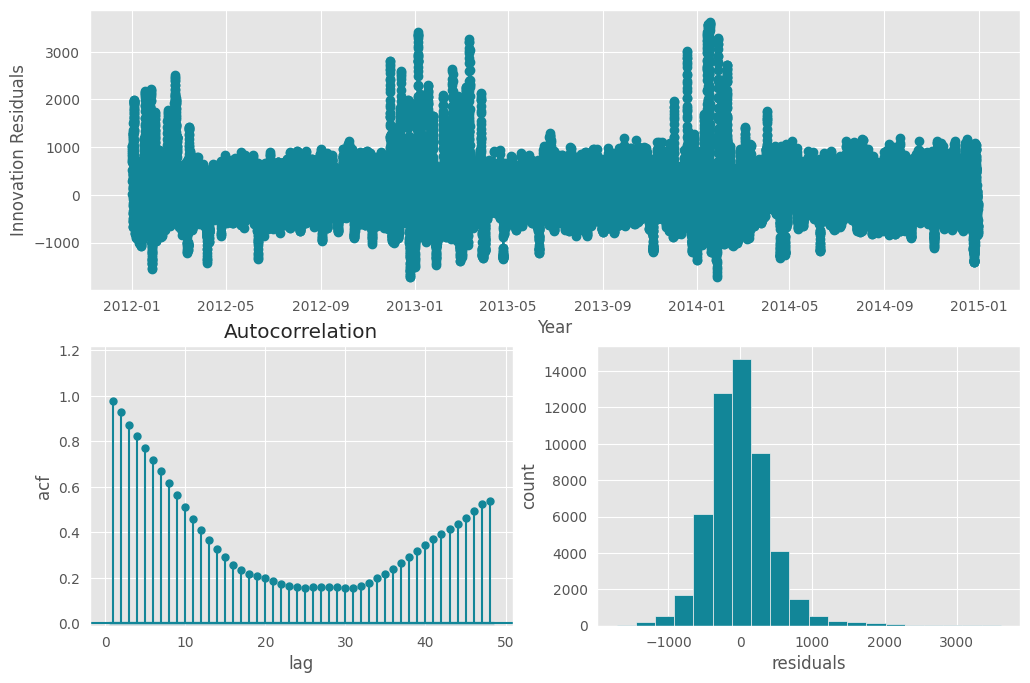

In [19]:
residuals = fc_prophet["resid"]

fig = plt.figure(figsize=(12, 8))

gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ax1.plot(fc_prophet["ds"], residuals, marker="o")
ax1.set_ylabel("Innovation Residuals")
ax1.set_xlabel("Year")

plot_acf(residuals.dropna(), ax2,
         zero=False,
         bartlett_confint=False,
         auto_ylims=True)
ax2.set_ylabel("acf")
ax2.set_xlabel("lag")

ax3.hist(residuals, bins=20)
ax3.set_ylabel("count")
ax3.set_xlabel("residuals")

plt.show()

We can compare `prophet`'s forecasts against the `MSTL` method

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


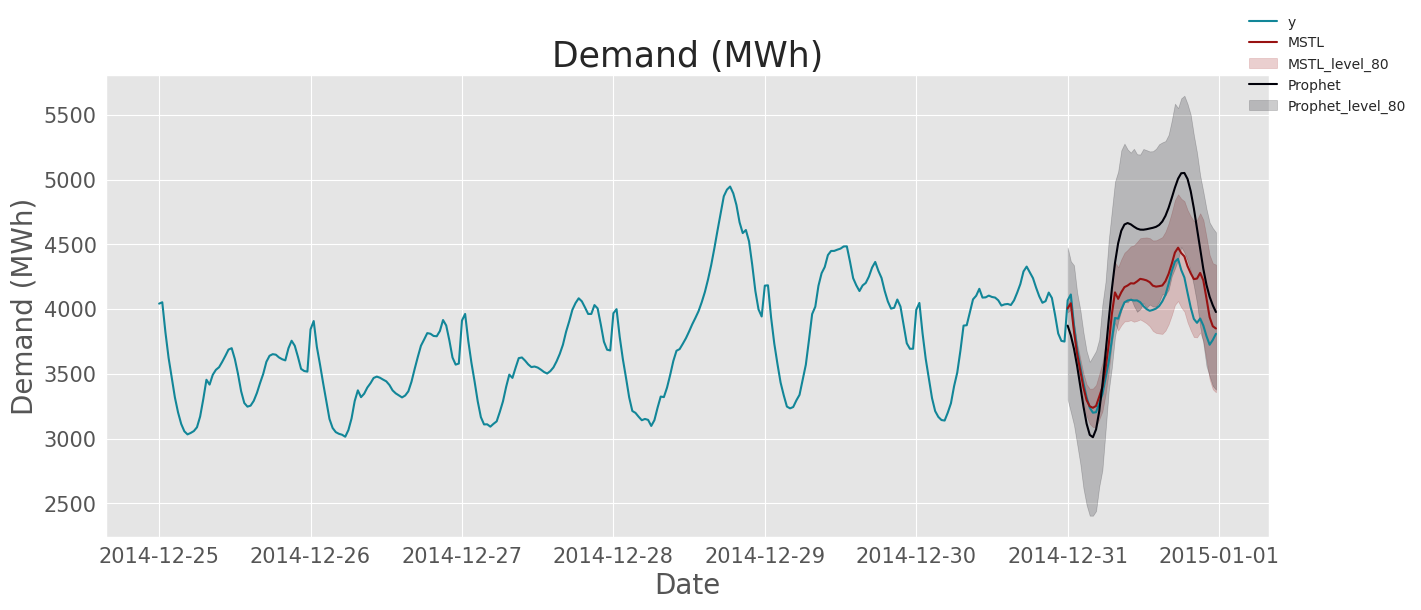

In [20]:
sf = StatsForecast(models=[MSTL(season_length=[48, 48 * 7])], freq="30T")
fc_stats = sf.forecast(df=train, h=48, level=[80])

fc = fc_stats.merge(fc_prophet[["ds", "Prophet", "Prophet-lo-80", "Prophet-hi-80"]], on=["ds"])
plot_series(vic_demand, fc, level=[80],
            max_insample_length=48 * 7,
            xlabel="Date", ylabel="Demand (MWh)",
            title = "Demand (MWh)",
            rm_legend=False)